Asah led by Dicoding 2025

**Capstone Project Team ID:** A25-CS327  
**Project Title:** *Customer Segmentation Using RFM Analysis and Clustering for Customer Value Profiling*  
**Selected Case:** AC-06 - Customer Segmentation for Personalized Retail Marketing  
**Capstone Advisor:** A25-AD196 - Raihan Nugroho Jauhari - 29/11/2025

| ID Member      | Name                     | Role              | Status   |
|----------------|--------------------------|-------------------|----------|
| M284D5Y0552    | Fadhil Muhamad           | Machine Learning  | Active   |
| M284D5Y1165    | Muh. Hilmy Fahrizal      | Machine Learning  | Active   |
| M015D5X1483    | Naysa Syifa Nuristiani   | Machine Learning  | Active   |


Import Librarry

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import datetime as dt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics import davies_bouldin_score
import matplotlib.ticker as mtick

Dataset source:

[**Online Retail II – UCI (Kaggle)**](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

In [2]:
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
print("Path to dataset files:", path)

100%|██████████| 14.5M/14.5M [00:03<00:00, 4.36MB/s]

Extracting files...


Path to dataset files: C:\Users\hilmy\.cache\kagglehub\datasets\mashlyn\online-retail-ii-uci\versions\3


In [3]:
import os

print(os.listdir(path))


['online_retail_II.csv']


# **Basic EDA**

In [4]:
df_raw = pd.read_csv(f"{path}/online_retail_II.csv")
df_raw.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
print("Shape:", df_raw.shape)
df_raw.dtypes

Shape: (1067371, 8)


Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

Check missing values & duplicates

In [7]:
print("Missing Values:")
print(df_raw.isnull().sum())
print()
print("Duplicate Rows:", df_raw.duplicated().sum())

Missing Values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate Rows: 34335


In [8]:
cat_cols = df_raw.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\nTotal nilai: {col}")
    print(df_raw[col].value_counts().head())


Total nilai: Invoice
Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
Name: count, dtype: int64

Total nilai: StockCode
StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
Name: count, dtype: int64

Total nilai: Description
Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
Name: count, dtype: int64

Total nilai: InvoiceDate
InvoiceDate
2010-12-06 16:57:00    1350
2010-12-09 14:09:00    1304
2010-12-07 15:28:00    1202
2010-12-06 09:58:00    1194
2010-12-03 11:36:00    1186
Name: count, dtype: int64

Total nilai: Country
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Name: count, dtype: int64


# **Pre-processing**

Explanation of Key Variables

- **Customer ID**  
  Used to uniquely identify each customer.

- **InvoiceDate**  
  Used to calculate **Recency** — how long it has been since the customer's last purchase.

- **Quantity**  
  Used to calculate **Monetary** — representing the number of items purchased.

- **Price**  
  Used to calculate **Monetary** — total spending is computed as:  
  **Total Monetary = Quantity × Price**

- **Invoice**  
  Used to calculate **Frequency** — indicating how many times a customer has made a purchase.

In [9]:
df = df_raw[['Customer ID', 'InvoiceDate', 'Quantity', 'Price', 'Invoice']].copy()
df.head()

,Customer ID,InvoiceDate,Quantity,Price,Invoice
0,13085.0,2009-12-01 07:45:00,12,6.95,489434
1,13085.0,2009-12-01 07:45:00,12,6.75,489434
2,13085.0,2009-12-01 07:45:00,12,6.75,489434
3,13085.0,2009-12-01 07:45:00,48,2.10,489434
4,13085.0,2009-12-01 07:45:00,24,1.25,489434



Handling Missing Values

In [10]:
print(f"Missing Customer ID: {df_raw['Customer ID'].isna().sum()}")

len_before = len(df)
df = df.dropna(subset=['Customer ID'])

print(f"After removing missing Customer ID: {len(df)} (Removed {len_before - len(df)} transactions)")

Missing Customer ID: 243007
After removing missing Customer ID: 824364 (Removed 243007 transactions)


Handling Canceled Transactions

In [11]:
len_before = len(df)

cancelation = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
df = df[~df['Invoice'].astype(str).str.startswith('C')]

cancelation_cols = ['Invoice', 'Customer ID', 'Quantity', 'Price']
print("\nSample of Credit Note / Return Transactions")
print(cancelation[cancelation_cols].head())

print(f"After removing credit notes: {len(df)} (removed {len_before - len(df)} transactions)")


Sample of Credit Note / Return Transactions
     Invoice  Customer ID  Quantity  Price
178  C489449      16321.0       -12   2.95
179  C489449      16321.0        -6   1.65
180  C489449      16321.0        -4   4.25
181  C489449      16321.0        -6   2.10
182  C489449      16321.0       -12   2.95
After removing credit notes: 805620 (removed 18744 transactions)


Handling Invalid Data

In [12]:
len_before = len(df)

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print(f"After removing Quantity/Price <= 0: {len(df)} (removed {len_before - len(df)} transactions)")

After removing Quantity/Price <= 0: 805549 (removed 71 transactions)


Handling Duplicates

In [13]:
len_before = len(df)

duplicates = df[df.duplicated(keep=False)]
if not duplicates.empty:
    print("\nExample of Duplicate Transactions")
    print(duplicates.head())

df = df.drop_duplicates()

print(f"After removing duplicates: {len(df)} (removed {len_before - len(df)} transactions)")


Example of Duplicate Transactions
   Customer ID          InvoiceDate  Quantity  Price Invoice
1      13085.0  2009-12-01 07:45:00        12   6.75  489434
2      13085.0  2009-12-01 07:45:00        12   6.75  489434
4      13085.0  2009-12-01 07:45:00        24   1.25  489434
6      13085.0  2009-12-01 07:45:00        24   1.25  489434
8      13085.0  2009-12-01 07:46:00        12   2.55  489435
After removing duplicates: 490658 (removed 314891 transactions)


Monotery Columns

In [14]:
df['Revenue'] = df['Quantity'] * df['Price']
print("\nRevenue Sample:")
print(df[['Quantity', 'Price', 'Revenue']].head())


Revenue Sample:
   Quantity  Price  Revenue
0        12   6.95     83.4
1        12   6.75     81.0
3        48   2.10    100.8
4        24   1.25     30.0
5        24   1.65     39.6


Data Transformation for Rencency

In [15]:
print("InvoiceDate dtype before:", df['InvoiceDate'].dtype)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\nInvoiceDate dtype after:", df['InvoiceDate'].dtype)

min_date = df['InvoiceDate'].min()
max_date = df['InvoiceDate'].max()

print(f"\nData covers from {min_date.date()} to {max_date.date()}")

reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print("\nReference date:", reference_date)


InvoiceDate dtype before: object

InvoiceDate dtype after: datetime64[ns]

Data covers from 2009-12-01 to 2011-12-09

Reference date: 2011-12-10 12:50:00


In [16]:
df.columns

Index(['Customer ID', 'InvoiceDate', 'Quantity', 'Price', 'Invoice',
       'Revenue'],
      dtype='object')

check data

In [17]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().reset_index()

num_customers = customer_revenue['Customer ID'].nunique()
total_revenue = customer_revenue['Revenue'].sum()

print(f"Total customer: {num_customers}")
print(f"Total revenue: {total_revenue:,.0f}")

Total customer: 5878
Total revenue: 12,903,089


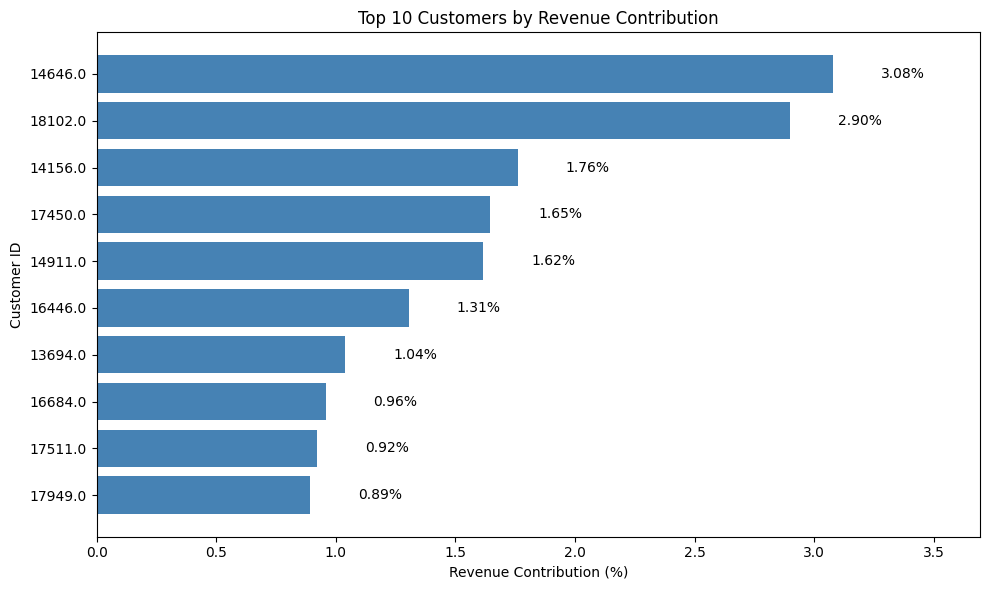

In [18]:
customer_revenue_sorted = customer_revenue.sort_values(by='Revenue', ascending=False)

top_n = 10
top_customers = customer_revenue_sorted.head(10).copy()
top_customers['Revenue_pct'] = top_customers['Revenue'] / total_revenue * 100

plt.figure(figsize=(10,6))
bars = plt.barh(
    y=top_customers['Customer ID'].astype(str),
    width=top_customers['Revenue_pct'],
    color='steelblue'
)

plt.gca().invert_yaxis()
plt.xlim(0, max(top_customers['Revenue_pct']) * 1.2)

for bar, pct in zip(bars, top_customers['Revenue_pct']):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{pct:.2f}%',
        va='center'
    )

plt.xlabel('Revenue Contribution (%)')
plt.ylabel('Customer ID')
plt.title('Top 10 Customers by Revenue Contribution')
plt.tight_layout()
plt.show()

In [19]:
print("\nMonths covered in the dataset:")
print(df['InvoiceDate'].dt.to_period('M').unique())


Months covered in the dataset:
<PeriodArray>
['2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06',
 '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01',
 '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08',
 '2011-09', '2011-10', '2011-11', '2011-12']
Length: 25, dtype: period[M]


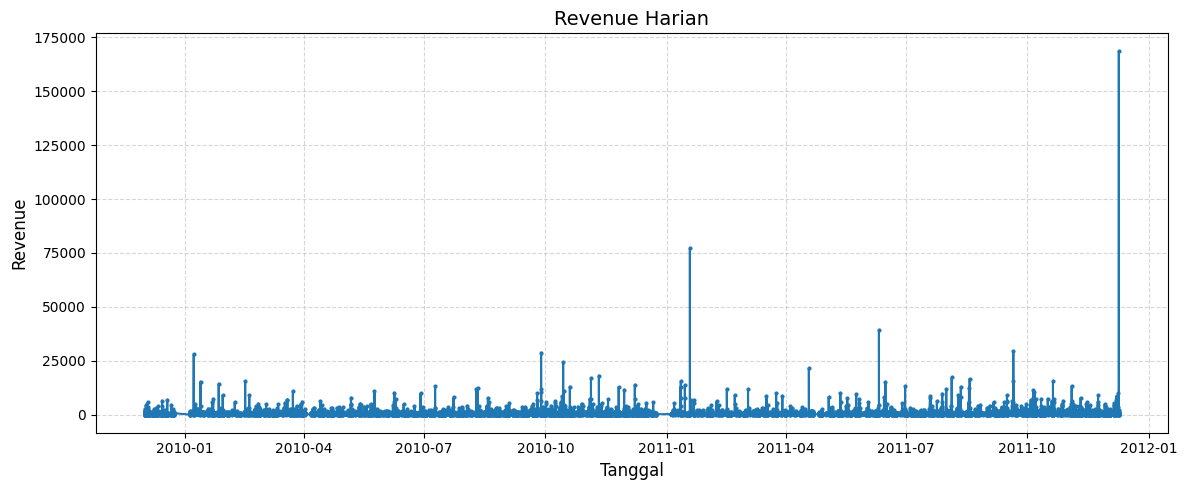

In [20]:
daily_revenue = df.groupby('InvoiceDate')['Revenue'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_revenue.index, daily_revenue, color='tab:blue', linewidth=1.5, marker='.', markersize=4)
plt.title('Revenue Harian', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

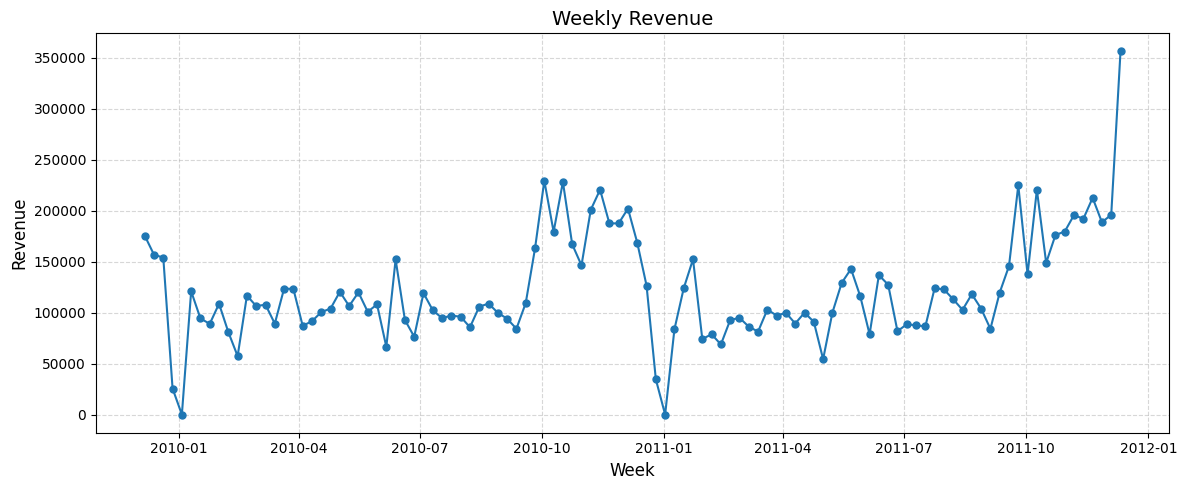

In [21]:
weekly_revenue = df.groupby('InvoiceDate')['Revenue'].sum().resample('W').sum()

plt.figure(figsize=(12,5))
plt.plot(weekly_revenue.index, weekly_revenue, color='tab:blue', linewidth=1.5, marker='o', markersize=5)
plt.title('Weekly Revenue', fontsize=14)
plt.xlabel('Week', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

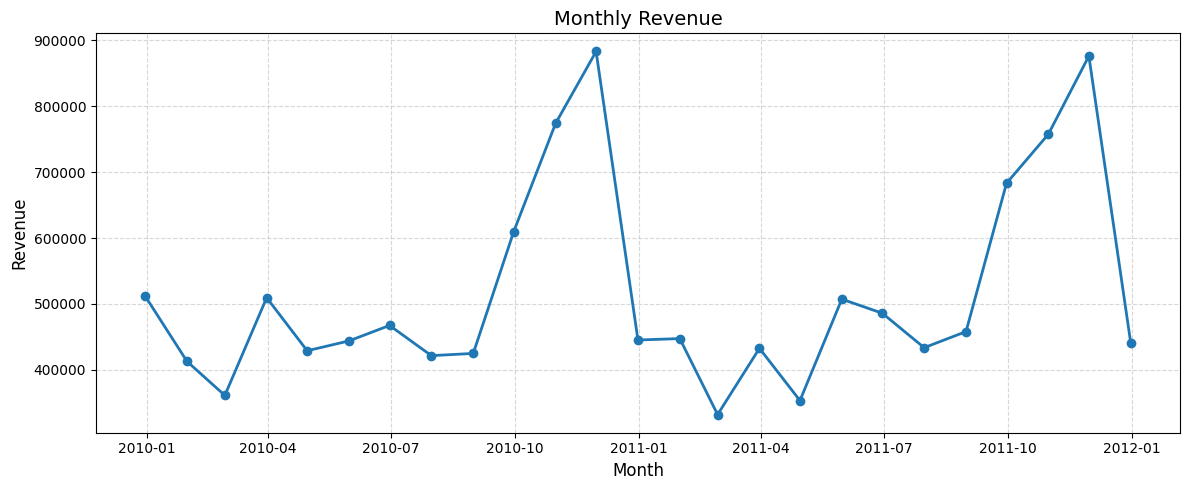

In [22]:
monthly_revenue = df.groupby('InvoiceDate')['Revenue'].sum().resample('ME').sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index, monthly_revenue, color='tab:blue', linewidth=2, marker='o', markersize=6)
plt.title('Monthly Revenue', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **RFM Analysis**

##### Recency (R)
- Measures how long it has been since a customer's last transaction.
- Calculated from the **reference_date** (the date used as the analysis reference).
- The smaller the recency value, the more recent the customer interaction.

##### Frequency (F)
- Measures how often a customer makes transactions.
- Calculated from the number of **unique invoices** per customer.
- The higher the frequency value, the more often the customer transacts.

##### Monetary (M)
- Measures the total spending of a customer.
- Calculated from the total **revenue** per customer.
- The higher the monetary value, the greater the customer's contribution.


~

- **Recency** = `reference_date - last_transaction_date`
- **Frequency** = `number_of_unique_invoices_per_customer`
- **Monetary** = `total_revenue_per_customer`

In [23]:
def calculate_rfm(df, reference_date):
    data = df.copy()
    rfm = (
        data.groupby('Customer ID')
            .agg({
                'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
                'Invoice': 'nunique',                                       # Frequency
                'Revenue': 'sum'                                            # Monetary
            })
            .rename(columns={
                'InvoiceDate': 'Recency',
                'Invoice': 'Frequency',
                'Revenue': 'Monetary'
            })
            .reset_index()
    )
    return rfm

rfm = calculate_rfm(df, reference_date)

print("\nExample of RFM table per customer:")
rfm.head()


Example of RFM table per customer:


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77403.79
1,12347.0,2,8,3434.23
2,12348.0,75,5,1448.56
3,12349.0,19,4,3018.85
4,12350.0,310,1,174.20


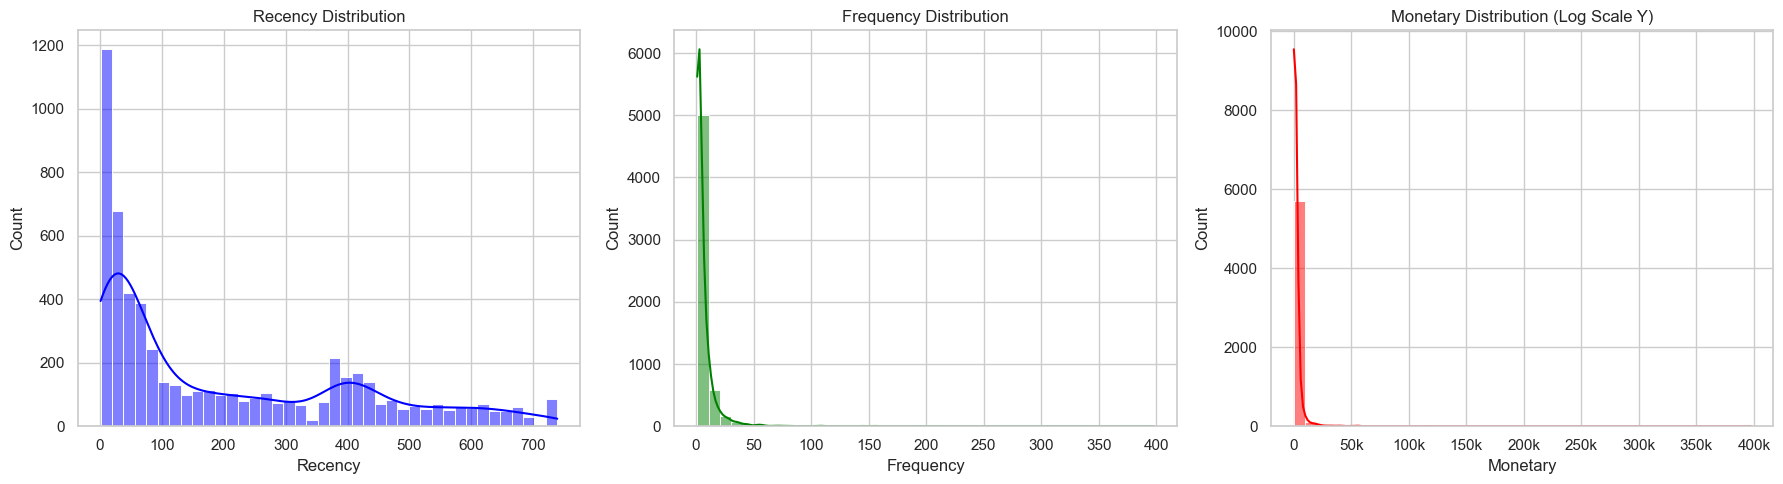

In [24]:
plt.figure(figsize=(18, 5))
sns.set_theme(style="whitegrid")

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], kde=True, bins=40, color='blue')
plt.title("Recency Distribution")

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], kde=True, bins=40, color='green')
plt.title("Frequency Distribution")

def thousands_formatter(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{int(x/1000)}k"
    else:
        return str(int(x))

plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], kde=True, bins=40, color='red')
plt.title("Monetary Distribution (Log Scale Y)")

plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()


### Monitoring (RFM Score)

In [25]:
R_Score = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
F_Score = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
M_Score = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm_score = pd.DataFrame({
    'Customer ID': rfm['Customer ID'],
    'R_Score': R_Score,
    'F_Score': F_Score,
    'M_Score': M_Score
})

rfm_score['RFM_Score'] = (
    rfm_score['R_Score'].astype(str) +
    rfm_score['F_Score'].astype(str) +
    rfm_score['M_Score'].astype(str)
)

print("\nExample of RFM Score")
rfm_score.head()


Example of RFM Score


,Customer ID,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,2,5,5,255
1,12347.0,5,4,5,545
2,12348.0,3,4,4,344
3,12349.0,5,3,5,535
4,12350.0,2,1,1,211


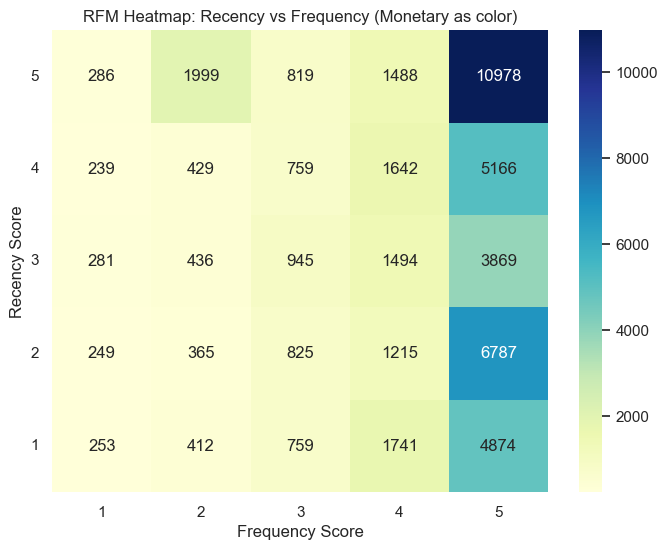

In [26]:
rfm_plot = rfm.join(rfm_score.set_index('Customer ID'), on='Customer ID')

heatmap_data = rfm_plot.groupby(['R_Score', 'F_Score'], observed=True)['Monetary'].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("RFM Heatmap: Recency vs Frequency (Monetary as color)")
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")

plt.yticks(rotation=0)
plt.show()

Data Normalisation

In [27]:
rfm_clust = rfm[['Recency','Frequency','Monetary']].copy()
scaler = MinMaxScaler()
rfm_scaled = scaler.fit_transform(rfm_clust)

# **Clustering**

Optimal Cluster

Optimal cluster based on combined score: k = 4


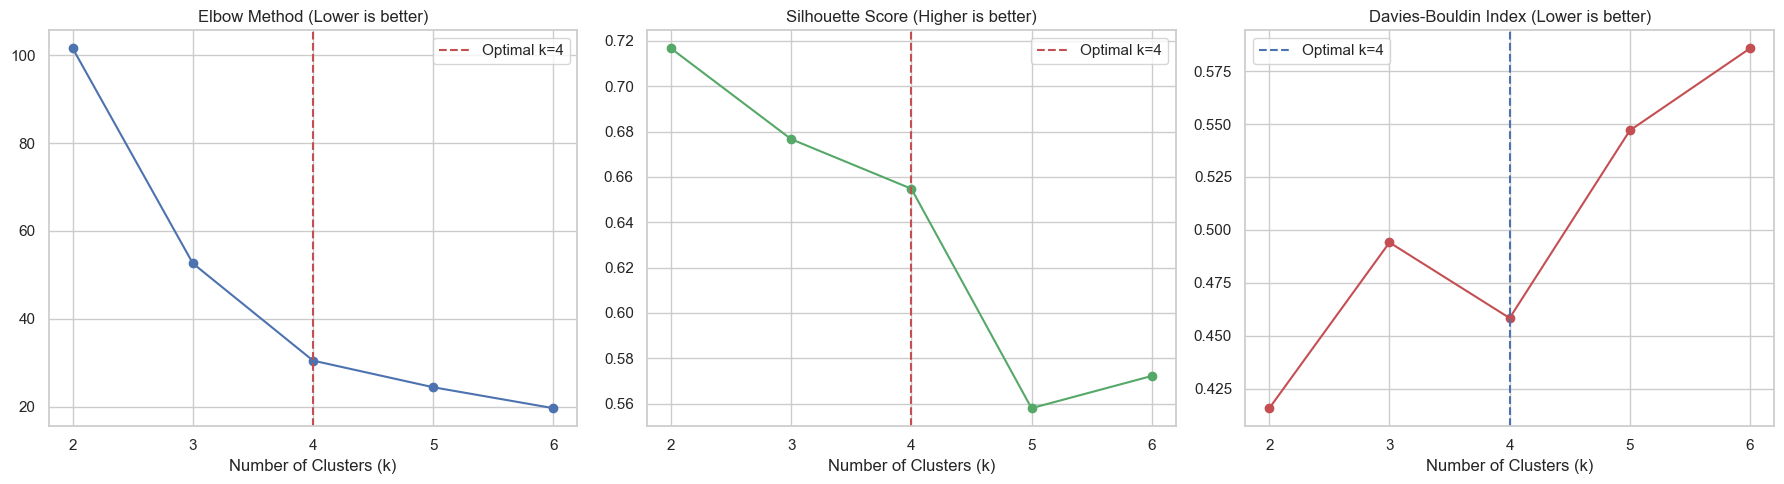

In [28]:
K = range(2, 7)
sse = []
sil_scores = []
dbi_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    sse.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    dbi_scores.append(davies_bouldin_score(rfm_scaled, labels))

sse_arr = np.array(sse).reshape(-1,1)
sse_norm = MinMaxScaler().fit_transform(sse_arr).flatten()

sil_arr = np.array(sil_scores).reshape(-1,1)
sil_norm = MinMaxScaler().fit_transform(sil_arr).flatten()

dbi_arr = np.array(dbi_scores).reshape(-1,1)
dbi_norm = MinMaxScaler().fit_transform(dbi_arr).flatten()

combined_scores = []
for i, k in enumerate(K):
    final_score = 0.33 * (1 - sse_norm[i]) + 0.34 * sil_norm[i] + 0.33 * (1 - dbi_norm[i])
    combined_scores.append((k, final_score))

k_opt = max(combined_scores, key=lambda x: x[1])[0]
print(f"Optimal cluster based on combined score: k = {k_opt}")

fig, axs = plt.subplots(1,3,figsize=(18,5))

# Elbow Method (SSE)
axs[0].plot(K, sse, marker='o', color='b')
axs[0].axvline(k_opt, color='r', linestyle='--', label=f'Optimal k={k_opt}')
axs[0].set_title('Elbow Method (Lower is better)')
axs[0].set_xlabel('Number of Clusters (k)')
axs[0].set_xticks(list(K))
axs[0].grid(True)
axs[0].legend()

# Silhouette Score
axs[1].plot(K, sil_scores, marker='o', color='g')
axs[1].axvline(k_opt, color='r', linestyle='--', label=f'Optimal k={k_opt}')
axs[1].set_title('Silhouette Score (Higher is better)')
axs[1].set_xlabel('Number of Clusters (k)')
axs[1].set_xticks(list(K))
axs[1].grid(True)
axs[1].legend()

# Davies-Bouldin Index
axs[2].plot(K, dbi_scores, marker='o', color='r')
axs[2].axvline(k_opt, color='b', linestyle='--', label=f'Optimal k={k_opt}')
axs[2].set_title('Davies-Bouldin Index (Lower is better)')
axs[2].set_xlabel('Number of Clusters (k)')
axs[2].set_xticks(list(K))
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

In [29]:
rfm.columns

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary'], dtype='object')

Modeling

In [30]:
kmeans_final = KMeans(n_clusters=k_opt, random_state=42)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

cluster_size = rfm['Cluster'].value_counts().sort_index()
cluster_size

Cluster
0     989
1    3145
2    1107
3     637
Name: count, dtype: int64

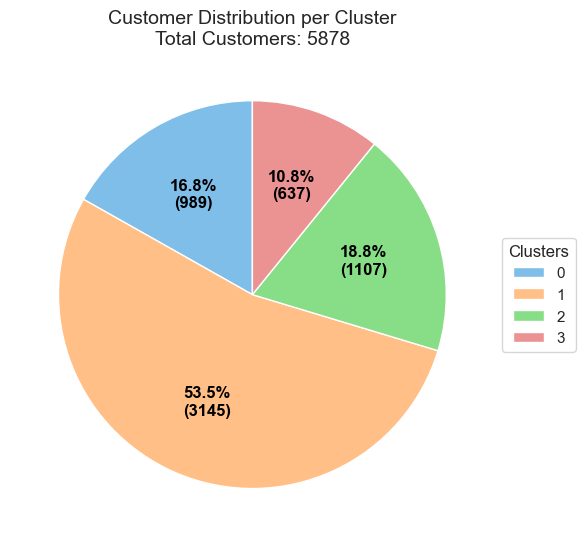

In [31]:
clusters = cluster_size.index
counts = cluster_size.values

base_colors = plt.cm.tab10.colors[:len(clusters)]

def lighten_color(color, amount=0.5):
    import colorsys
    try:
        c = mcolors.cnames[color]
    except:
        c = color
    c = mcolors.to_rgb(c)
    c = colorsys.rgb_to_hls(*c)

    lightened = colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])
    return lightened

colors = [lighten_color(c, 0.5) for c in base_colors]

def autopct_format(pct, all_vals):
    absolute = int(round(pct/100.*sum(all_vals)))
    return f"{pct:.1f}%\n({absolute})"

fig, ax = plt.subplots(figsize=(6,6))

pie_result = ax.pie(
    counts,
    labels=None,
    autopct=lambda pct: autopct_format(pct, counts),
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12, 'color': 'black', 'weight': 'bold'}
)

wedges = pie_result[0]

ax.legend(wedges, clusters, title="Clusters", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax.set_title(f"Customer Distribution per Cluster\nTotal Customers: {counts.sum()}", fontsize=14)

plt.tight_layout()
plt.show()


In [32]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_profile_units = cluster_profile.rename(columns={
    'Recency': 'Recency (days)',
    'Frequency': 'Frequency (purchases)',
    'Monetary': 'Monetary (£)'
})

cluster_profile_units

,Recency (days),Frequency (purchases),Monetary (£)
Cluster,,,
0,213.31,3.71,1032.79
1,37.89,9.31,3416.97
2,412.85,2.72,751.34
3,622.08,1.55,476.54


In [33]:
cluster_profile_median = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].median().round()
cluster_profile_median

,Recency,Frequency,Monetary
Cluster,,,
0,211.0,3.0,497.0
1,29.0,5.0,1151.0
2,409.0,2.0,340.0
3,619.0,1.0,194.0


In [34]:
ratio_mean_median = (cluster_profile / cluster_profile_median).round(2)
print("Mean / Median Ratio per cluster:")
ratio_mean_median

Mean / Median Ratio per cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,1.01,1.24,2.08
1,1.31,1.86,2.97
2,1.01,1.36,2.21
3,1.00,1.55,2.46


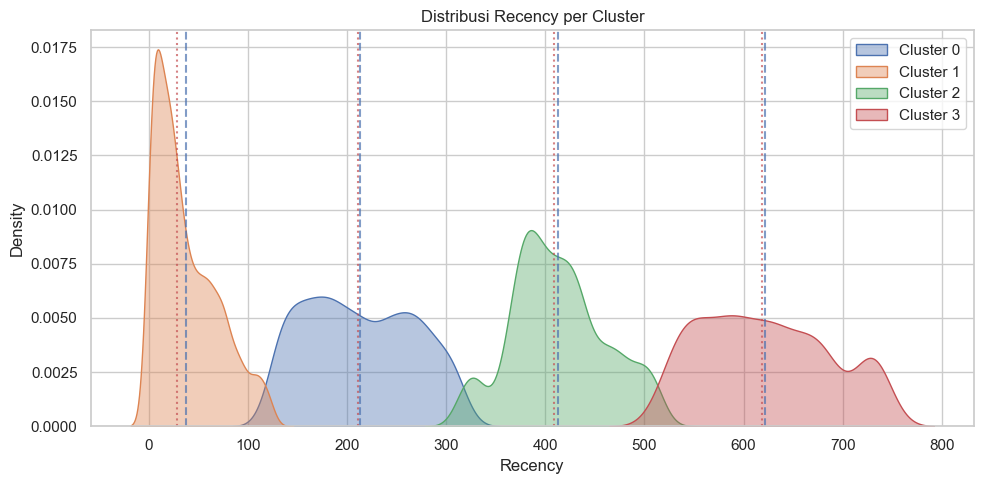

In [35]:
col = 'Recency'
num_clusters = cluster_profile.shape[0]

plt.figure(figsize=(10,5))

for cluster in range(num_clusters):
    sns.kdeplot(
        rfm[rfm['Cluster']==cluster][col],
        label=f'Cluster {cluster}',
        fill=True, alpha=0.4
    )
    plt.axvline(cluster_profile.loc[cluster, col], color='b', linestyle='--', alpha=0.7)
    plt.axvline(cluster_profile_median.loc[cluster, col], color='r', linestyle=':', alpha=0.7)

plt.title('Distribusi Recency per Cluster')
plt.xlabel('Recency')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


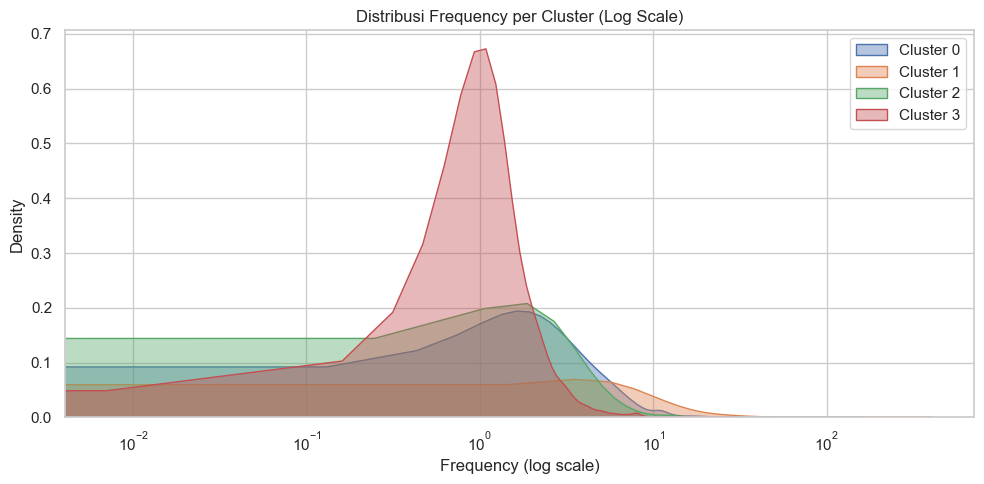

In [36]:
col = 'Frequency'
num_clusters = cluster_profile.shape[0]

plt.figure(figsize=(10,5))

for cluster in range(num_clusters):
    sns.kdeplot(
        rfm[rfm['Cluster']==cluster][col],
        label=f'Cluster {cluster}',
        fill=True, alpha=0.4
    )

plt.xscale('log')
plt.title('Distribusi Frequency per Cluster (Log Scale)')
plt.xlabel('Frequency (log scale)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


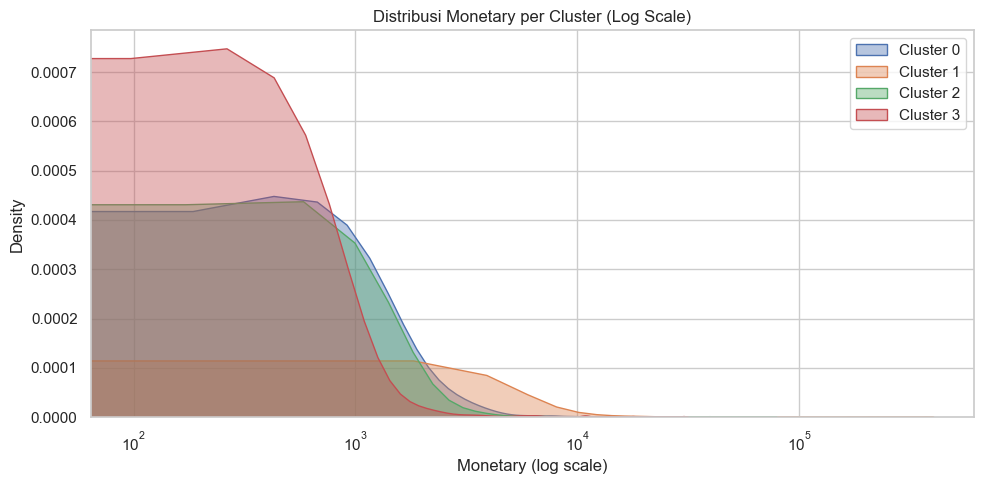

In [37]:
col = 'Monetary'
num_clusters = cluster_profile.shape[0]

plt.figure(figsize=(10,5))

for cluster in range(num_clusters):
    sns.kdeplot(
        rfm[rfm['Cluster']==cluster][col],
        label=f'Cluster {cluster}',
        fill=True, alpha=0.4
    )

plt.xscale('log')
plt.title('Distribusi Monetary per Cluster (Log Scale)')
plt.xlabel('Monetary (log scale)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


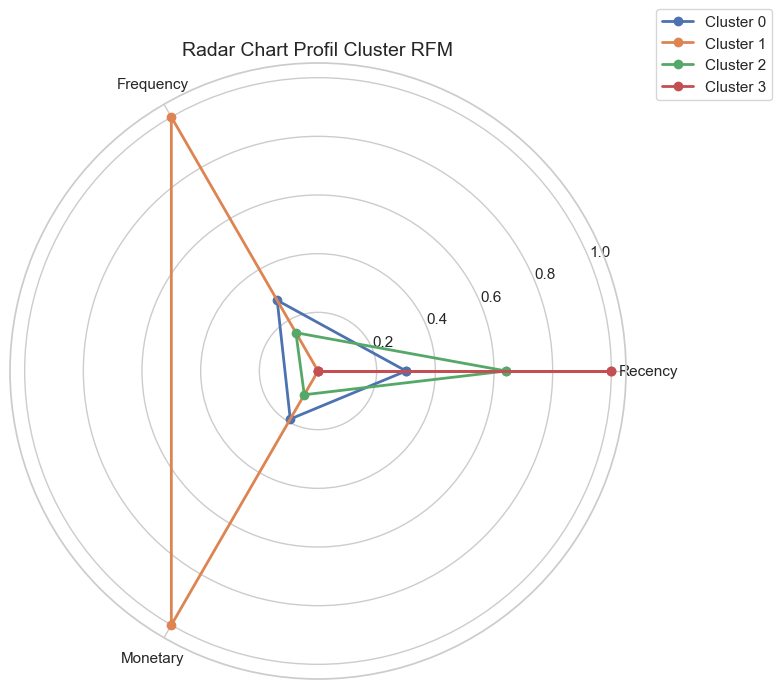

In [38]:
rfm_cols = ['Recency', 'Frequency', 'Monetary']
N = len(rfm_cols)

cluster_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(8,8))

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for idx, row in cluster_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    plt.polar(angles, values, marker='o', linewidth=2, label=f'Cluster {idx}')

plt.xticks(angles[:-1], rfm_cols)
plt.title("Radar Chart Profil Cluster RFM", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.show()